<a href="https://colab.research.google.com/github/akshudurairaj/Applied-Machine-Learning/blob/main/ML_IRIS_dataset(decision_tree).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#ML lab numpy assignment(related to data set)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [ ]:
import pandas as pd

df = pd.read_csv("Iris.csv")

In [ ]:
# Check the dataset
print("Rows and columns:", df.shape)
df.info()

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Remove Id column
df = df.drop("Id", axis=1, errors="ignore")

# Check Species values
print("\nSpecies value counts:")
print(df["Species"].value_counts())

# Display first 5 rows
print("\nFirst 5 rows:")
print(df.head())

Rows and columns: (150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Missing values:
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Number of duplicate rows: 3

Species value counts:
Species
0    50
2    49
1    48
Name: count, dtype: int64

First 5 rows:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0            5.1           3.5            1.4           0.2        1
1            4.9           3.0            1.4           0.2        1
2            4.7           3.2            1.3         

In [ ]:
X = df[[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]].values

y = df["Species"].values

print("X:")
print(X[:5])

print("\ny:")
print(y[:5])

X:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

y:
[1 1 1 1 1]


In [ ]:
# Check for null/missing values
print("Null values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())
# Check null values
if df.isnull().values.any():
    print("There are null values.")
else:
    print("There are no null values.")

# Check duplicates
if df.duplicated().any():
    print("There are duplicate rows.")
else:
    print("There are no duplicate rows.")


Null values:
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Number of duplicate rows:
3
There are no null values.
There are duplicate rows.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (120, 4)
X_test: (30, 4)
y_train: (120,)
y_test: (30,)


In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print("Scaled X_train:")
print(X_train[:5])


Scaled X_train:
[[ 0.61303014  0.10850105  0.94751783  0.73603967]
 [-0.56776627 -0.12400121  0.38491447  0.34808318]
 [-0.80392556  1.03851009 -1.30289562 -1.3330616 ]
 [ 0.25879121 -0.12400121  0.60995581  0.73603967]
 [ 0.61303014 -0.58900572  1.00377816  1.25331499]]


In [ ]:
# Fitting Decision Tree Classification to the Training set

from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(
    criterion="entropy",
    random_state=0
)

# Train the classifier
classifier.fit(X_train, y_train)

print("Decision Tree trained successfully!")


Decision Tree trained successfully!


In [ ]:
# Predict the Test set results

y_pred = classifier.predict(X_test)

print("Predicted values:")
print(y_pred)

print("\nActual values:")
print(y_test)


Predicted values:
[2 0 1 2 1 2 1 0 0 0 2 0 0 0 0 1 0 0 1 1 2 0 1 1 2 1 1 0 0 1]

Actual values:
[2 0 1 2 1 2 1 0 0 0 2 0 0 0 0 1 0 0 1 1 2 0 1 1 2 1 1 0 0 1]


In [ ]:
# Making the Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[13  0  0]
 [ 0 11  0]
 [ 0  0  6]]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)


Accuracy: 1.0
Accuracy (%): 100.0


In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



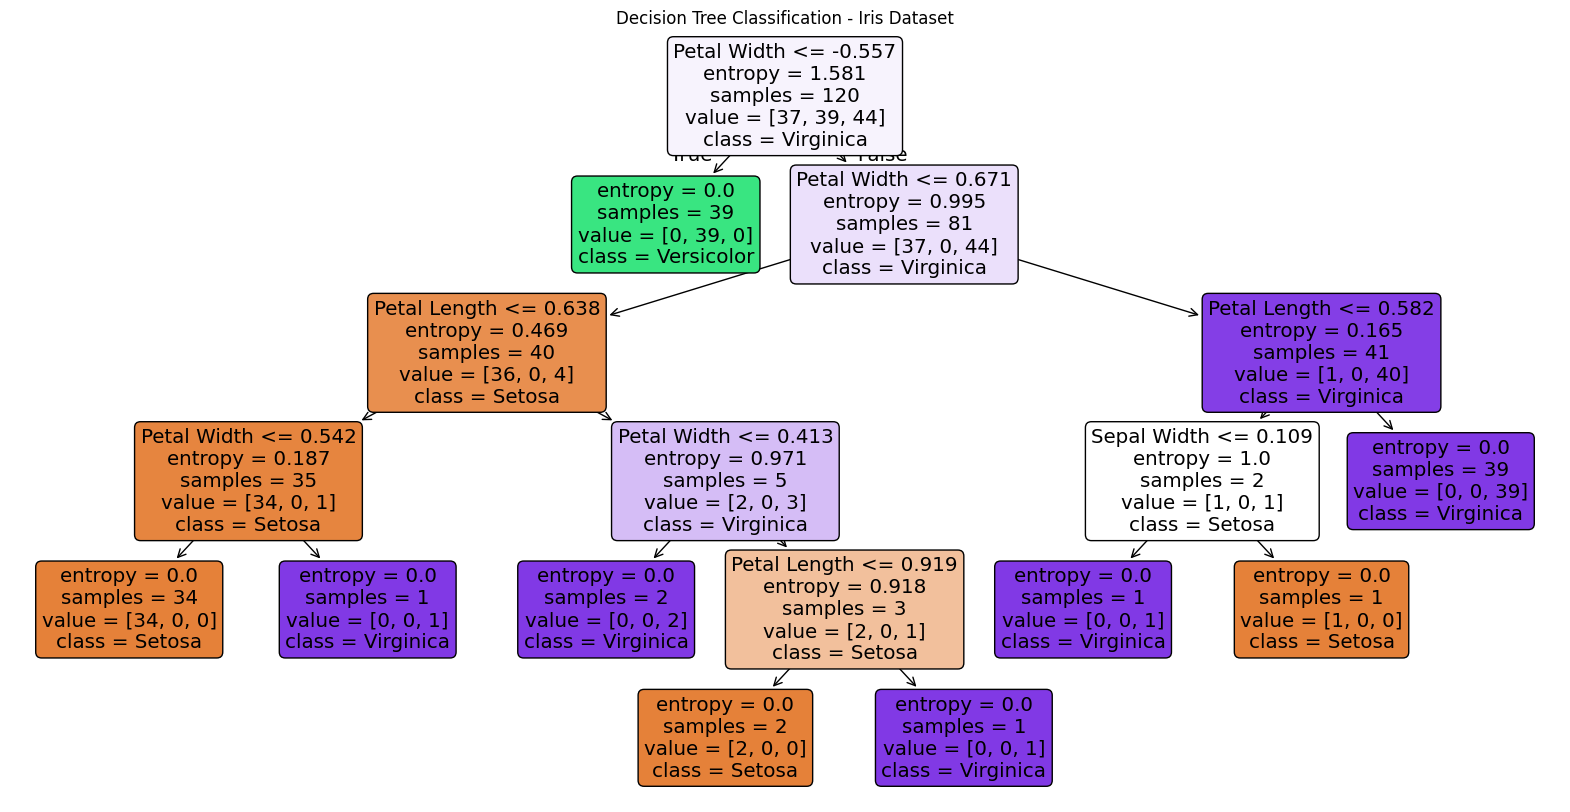

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    classifier,
    feature_names=[
        "Sepal Length",
        "Sepal Width",
        "Petal Length",
        "Petal Width"
    ],
    class_names=["Setosa", "Versicolor", "Virginica"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree Classification - Iris Dataset")
plt.show()
